In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# Notebook magic removed for .py / Kaggle script compatibility.
# %matplotlib inline

RANDOM_STATE = 42



In [2]:
df = pd.read_csv("/kaggle/input/siim-isic-melanoma-classification/train.csv")



In [3]:
df.head()



,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
3,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0
4,ISIC_0074311,IP_2950485,female,40.0,lower extremity,unknown,benign,0


In [4]:
df.shape



(28984, 8)

In [5]:
df.dtypes.value_counts().sort_values(ascending=False)



object     6
float64    1
int64      1
Name: count, dtype: int64

In [6]:
df.select_dtypes("object").apply(pd.Series.nunique, axis=0)



image_name                       28984
patient_id                        2056
sex                                  2
anatom_site_general_challenge        6
diagnosis                            9
benign_malignant                     2
dtype: int64

In [7]:
df["patient_id"].value_counts()



patient_id
IP_4382720    104
IP_0656529    102
IP_4938382    101
IP_7279968     98
IP_4479736     97
             ... 
IP_8124488      1
IP_3278850      1
IP_8598620      1
IP_5068447      1
IP_8007315      1
Name: count, Length: 2056, dtype: int64

In [8]:
df["patient_id"].value_counts().mean()



14.09727626459144

In [9]:
df["target"].value_counts()




target
0    28471
1      513
Name: count, dtype: int64

In [10]:
def plot_analysis(col_name, df, plot_kind="bar"):
    """
    Plot benign vs malignant value counts for a feature.
    """
    df_benign = df[df["target"] == 0]
    df_malignant = df[df["target"] != 0]

    fig, axs = plt.subplots(2, figsize=(26, 8))
    fig.suptitle(
        "Difference between " + col_name + " of patients in benign and malignant cases "
    )
    axs[0].set_title("Benign")
    axs[0].set_ylabel("Number of cases", fontsize=12)
    axs[1].set_title("Malignant")
    axs[1].set_ylabel("Number of cases", fontsize=12)
    axs[1].set_xlabel(col_name, fontsize=12)

    if plot_kind == "line":
        axs[0].plot(
            df_benign[col_name].value_counts().index,
            df_benign[col_name].value_counts().values,
        )
        axs[1].plot(
            df_malignant[col_name].value_counts().index,
            df_malignant[col_name].value_counts().values,
        )
    elif plot_kind == "bar":
        axs[0].bar(
            df_benign[col_name].value_counts().index,
            df_benign[col_name].value_counts().values,
        )
        axs[1].bar(
            df_malignant[col_name].value_counts().index,
            df_malignant[col_name].value_counts().values,
        )

    return True




True

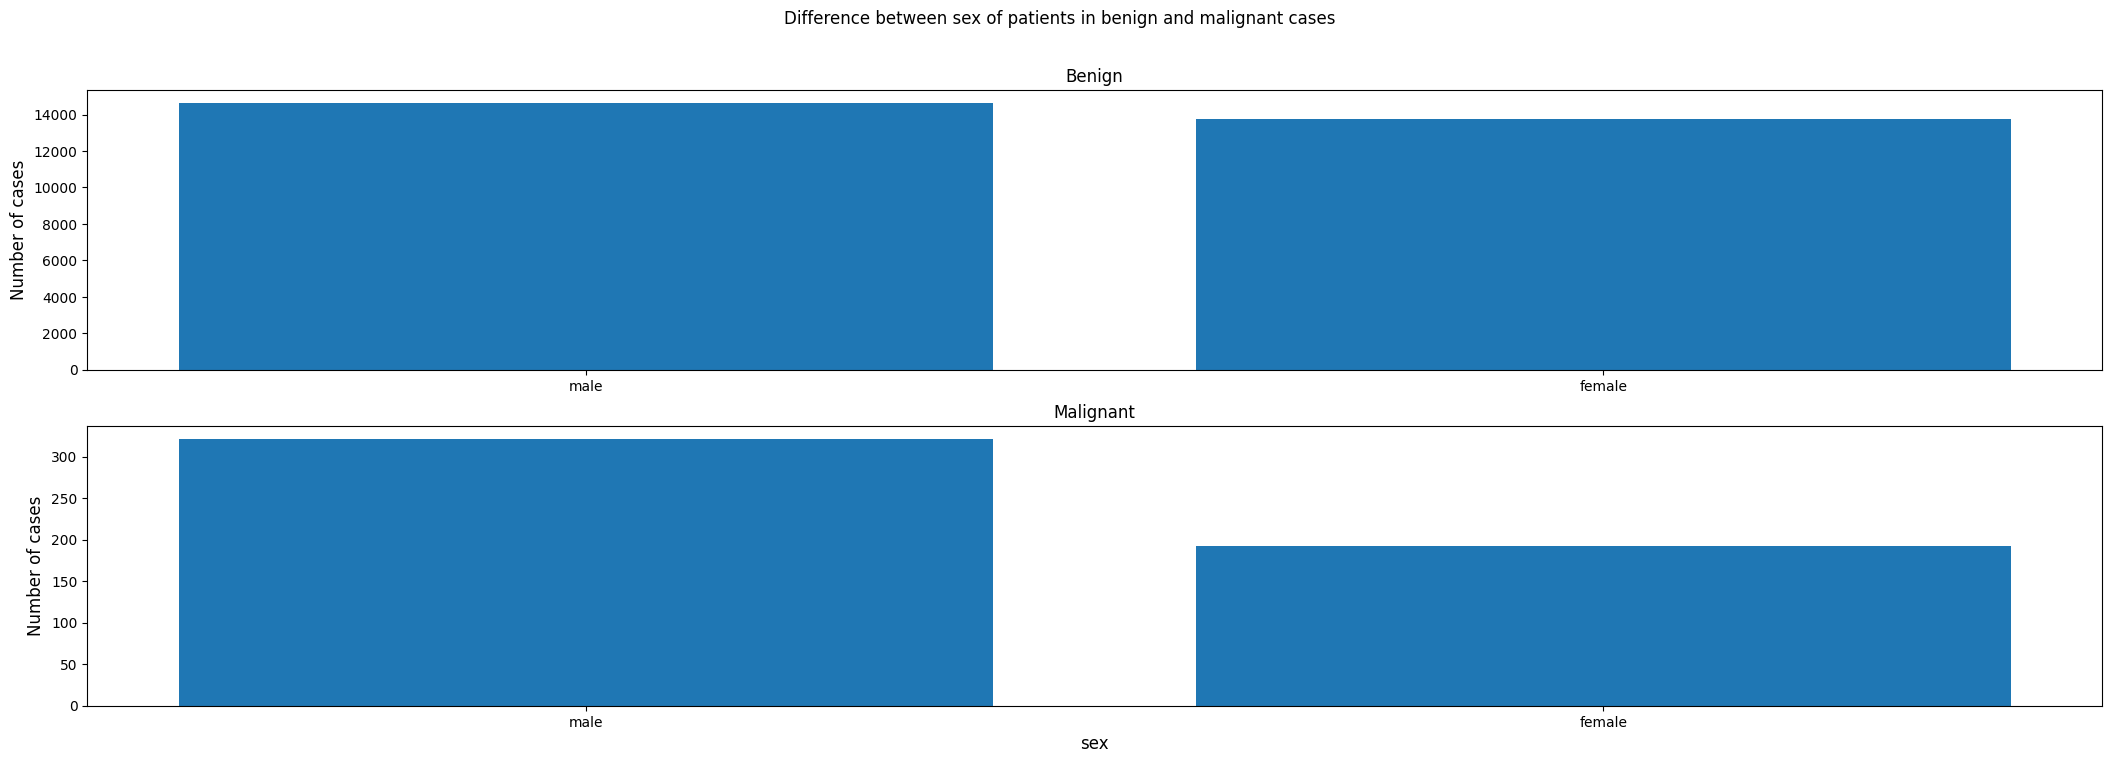

In [11]:
plot_analysis("sex", df)



True

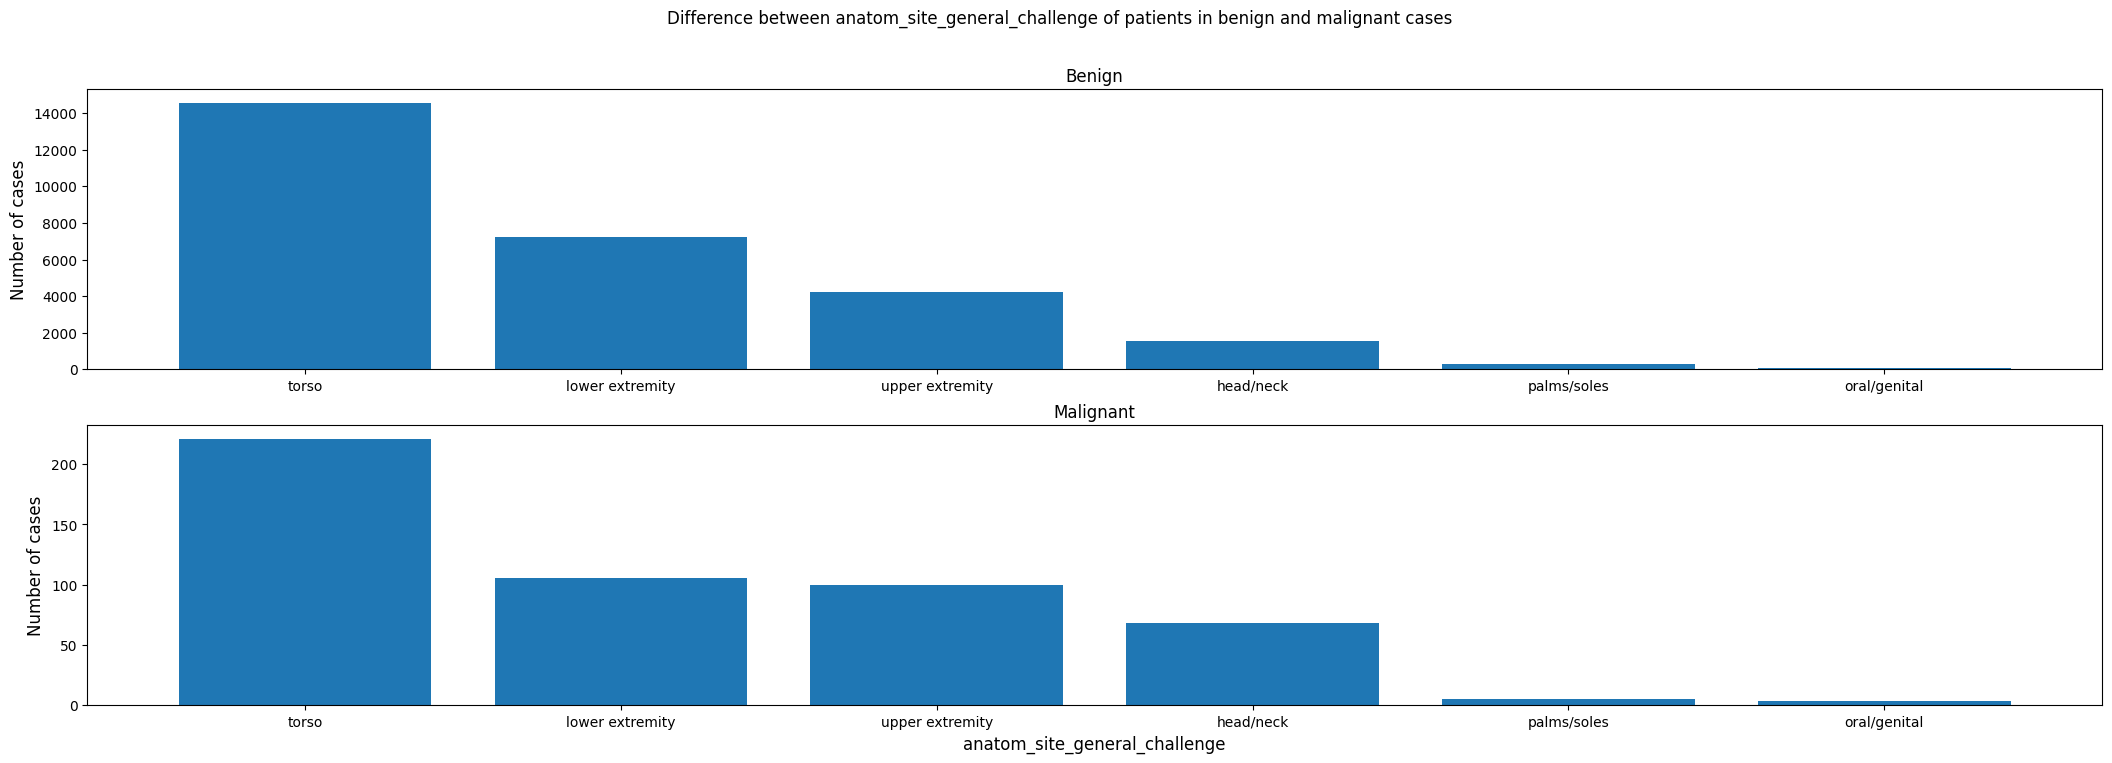

In [12]:
plot_analysis("anatom_site_general_challenge", df)



True

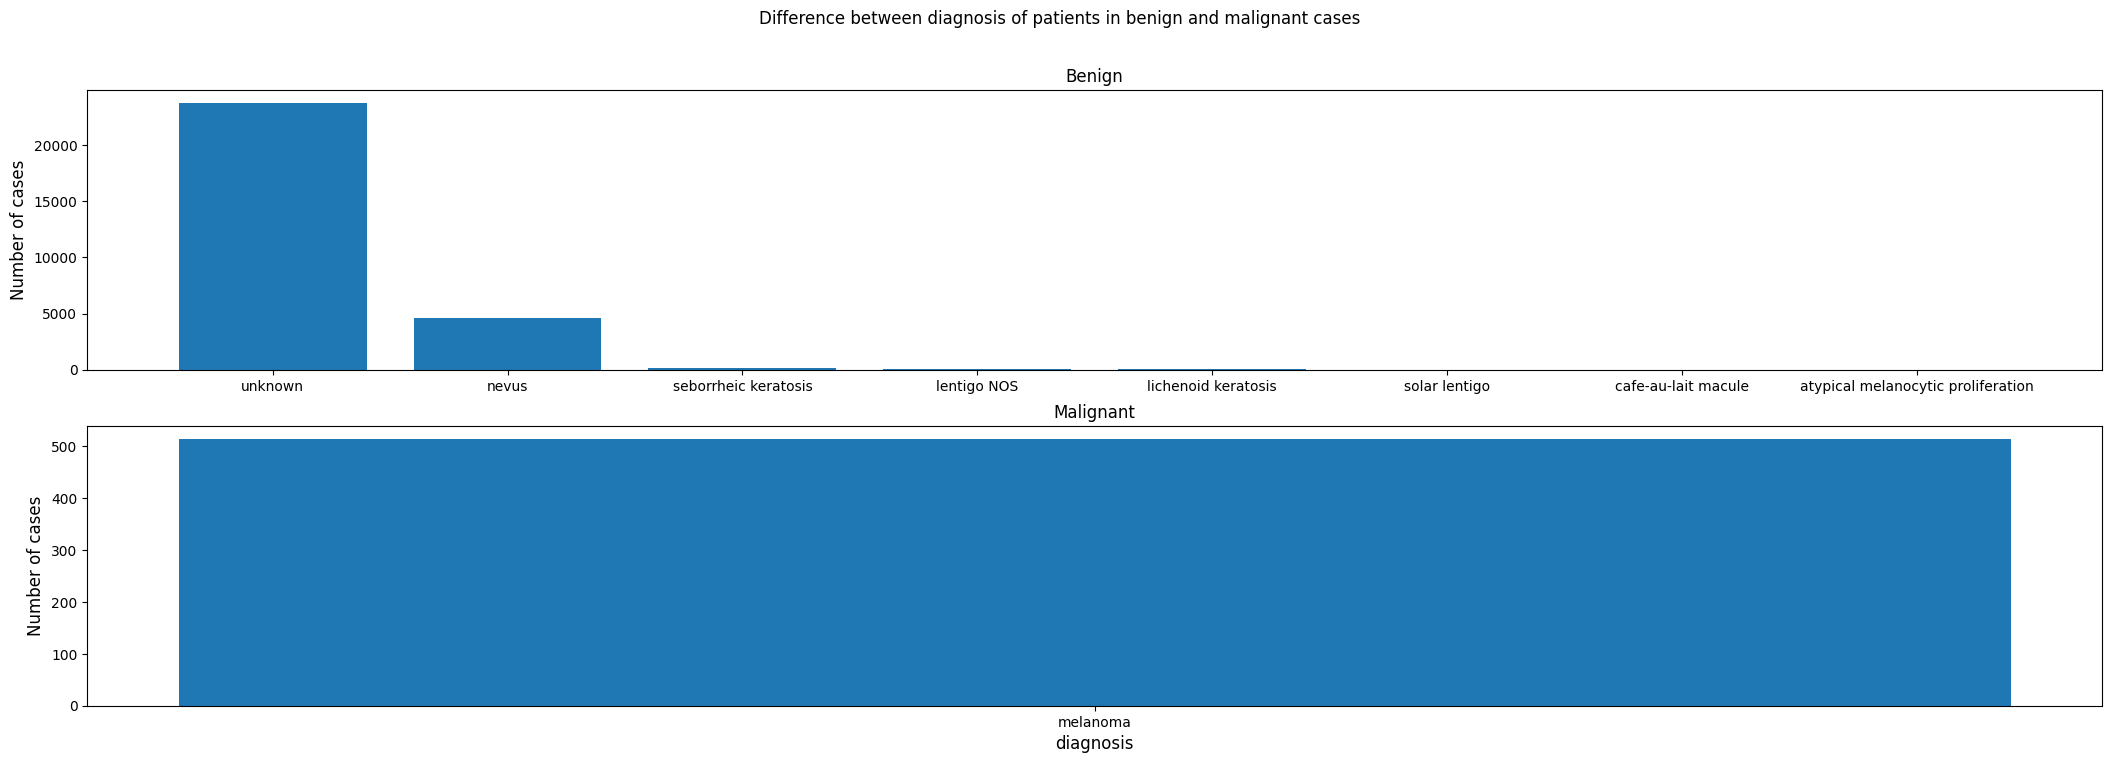

In [13]:
plot_analysis("diagnosis", df)



True

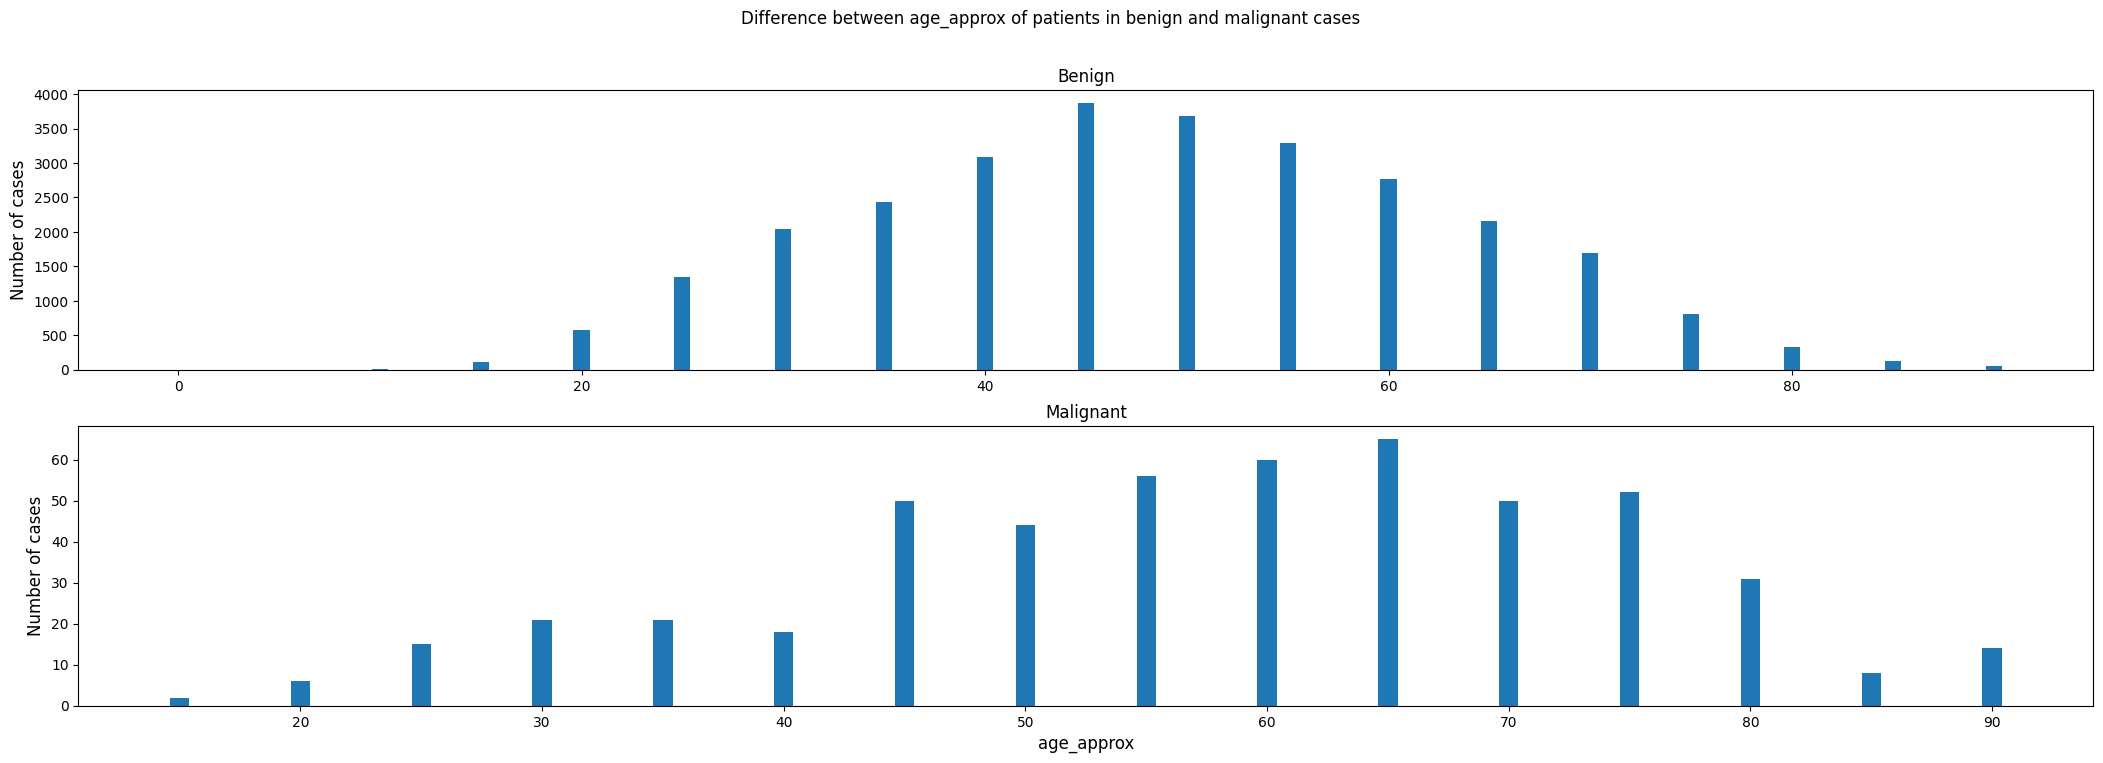

In [14]:
plot_analysis("age_approx", df)



In [15]:
df.isnull().sum()




image_name                         0
patient_id                         0
sex                               56
age_approx                        59
anatom_site_general_challenge    466
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64

In [16]:
# Bugfix + stability: ensure train/test preprocessing uses the same fitted encoders and the same one-hot columns.
# Core logic preserved (same fills, label encoding for sex, get_dummies for anatom_site).
def data_preparation_fit(train_df: pd.DataFrame):
    train_df = train_df.copy()

    train_df["sex"] = train_df["sex"].fillna("male")
    train_df["age_approx"] = train_df["age_approx"].fillna(
        train_df["age_approx"].mean()
    )
    train_df["anatom_site_general_challenge"] = train_df[
        "anatom_site_general_challenge"
    ].fillna("torso")

    le_sex = LabelEncoder()
    train_df["sex"] = le_sex.fit_transform(train_df["sex"])

    train_df = pd.get_dummies(train_df, columns=["anatom_site_general_challenge"])

    X = train_df.drop(
        ["image_name", "patient_id", "benign_malignant", "target", "diagnosis"], axis=1
    )
    y = train_df["target"].astype(int)

    feature_columns = X.columns.tolist()
    return X, y, le_sex, feature_columns


def data_preparation_transform(df: pd.DataFrame, le_sex: LabelEncoder, feature_columns):
    df = df.copy()

    df["sex"] = df["sex"].fillna("male")
    # Use its own mean if age_approx missing; evaluation metric doesn't require identical mean,
    # but this matches original intent and keeps behavior stable.
    df["age_approx"] = df["age_approx"].fillna(df["age_approx"].mean())
    df["anatom_site_general_challenge"] = df["anatom_site_general_challenge"].fillna(
        "torso"
    )

    # Handle any unseen sex values robustly (shouldn't happen, but avoids crashes).
    # If unseen, map to most frequent known class ('male' after fill) by default.
    known = set(le_sex.classes_)
    df["sex"] = df["sex"].where(df["sex"].isin(known), le_sex.classes_[0])
    df["sex"] = le_sex.transform(df["sex"])

    df = pd.get_dummies(df, columns=["anatom_site_general_challenge"])

    X = df.drop(["image_name", "patient_id"], axis=1)

    # Align columns to training features (prevents column mismatch at predict time).
    X = X.reindex(columns=feature_columns, fill_value=0)

    return X




In [17]:
X, y, le_sex, feature_columns = data_preparation_fit(df)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y
)

clf = LGBMClassifier(
    objective="binary",
    n_estimators=100000,
    num_leaves=10,
    learning_rate=0.001,
    max_depth=16,
    subsample_for_bin=200000,
    subsample=1,
    subsample_freq=200,
    silent=-1,
    verbose=-1,
    min_split_gain=0.0001,
    min_child_samples=800,
)

# Bugfix: lightgbm==4.6.0 no longer accepts verbose/early_stopping_rounds in .fit();
# use callbacks to preserve the same training semantics.
clf.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[
        log_evaluation(period=200),
        early_stopping(stopping_rounds=1000, first_metric_only=True),
    ],
)



Training until validation scores don't improve for 1000 rounds
[200]	training's auc: 0.701142	training's binary_logloss: 0.0871745	valid_1's auc: 0.691342	valid_1's binary_logloss: 0.0863689
[400]	training's auc: 0.702863	training's binary_logloss: 0.0861243	valid_1's auc: 0.691035	valid_1's binary_logloss: 0.0852006
[600]	training's auc: 0.706529	training's binary_logloss: 0.0853486	valid_1's auc: 0.697669	valid_1's binary_logloss: 0.0843812
[800]	training's auc: 0.70646	training's binary_logloss: 0.0848309	valid_1's auc: 0.696533	valid_1's binary_logloss: 0.0838796
[1000]	training's auc: 0.708088	training's binary_logloss: 0.0844247	valid_1's auc: 0.697862	valid_1's binary_logloss: 0.0834048
Early stopping, best iteration is:
[1]	training's auc: 0.687761	training's binary_logloss: 0.0889807	valid_1's auc: 0.700347	valid_1's binary_logloss: 0.0884999
Evaluated only: auc


LGBMClassifier(learning_rate=0.001, max_depth=16, min_child_samples=800,
               min_split_gain=0.0001, n_estimators=100000, num_leaves=10,
               objective='binary', silent=-1, subsample=1, subsample_freq=200,
               verbose=-1)

In [18]:
test_df = pd.read_csv("/kaggle/input/siim-isic-melanoma-classification/test.csv")
test_df.head()



,image_name,patient_id,sex,age_approx,anatom_site_general_challenge
0,ISIC_0052212,IP_2842074,female,50.0,lower extremity
1,ISIC_0076545,IP_9802602,male,55.0,upper extremity
2,ISIC_0085172,IP_1705144,female,50.0,lower extremity
3,ISIC_0086709,IP_4109313,male,30.0,torso
4,ISIC_0109568,IP_0825081,male,80.0,lower extremity


In [19]:
eval_X = data_preparation_transform(
    test_df, le_sex=le_sex, feature_columns=feature_columns
)



In [20]:
prediction_list = clf.predict_proba(eval_X)
final_pred_list = prediction_list[:, 1].astype(float)



In [21]:
test_df = test_df.copy()
test_df["target"] = final_pred_list



In [22]:
submission = test_df[["image_name", "target"]].copy()
submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Wrote submission.csv with shape:", submission.shape)

     image_name    target
0  ISIC_0052212  0.017702
1  ISIC_0076545  0.017711
2  ISIC_0085172  0.017702
3  ISIC_0086709  0.017710
4  ISIC_0109568  0.017765
Wrote submission.csv with shape: (4142, 2)
